In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [3]:
# load data
df = pd.read_csv("df.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,date,open,high,low,close,volume,log_return,proxy_realised_variance,proxy_realised_volatility,realized_variance,...,blockchain_log_transaction_volume+usd,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,RV_1,RV_7,RV_30,target
0,2016-02-01,367.89,379.00,366.26,371.33,7931.229229,0.009144,0.000084,0.009144,0.000424,...,19.045754,0.233729,0.463983,0.019566,0.589070,8.978689,0.020584,NaN,NaN,0.008650
1,2016-02-02,371.33,374.41,371.17,372.93,6856.218158,0.004300,0.000018,0.004300,0.000075,...,18.940304,0.083320,0.108519,0.173418,-0.105450,8.833057,0.008650,NaN,NaN,0.010256
2,2016-02-03,372.93,373.01,365.63,368.87,7147.956573,-0.010946,0.000120,0.010946,0.000105,...,18.567064,-0.234343,-0.290071,-0.282119,-0.373240,8.874722,0.010256,NaN,NaN,0.031438
3,2016-02-04,368.87,390.63,368.74,387.99,8887.757232,0.050535,0.002554,0.050535,0.000988,...,18.798095,0.048171,-0.157233,0.064870,0.231030,9.092543,0.031438,NaN,NaN,0.014855
4,2016-02-05,387.99,389.36,382.99,384.50,7443.929332,-0.009036,0.000082,0.009036,0.000221,...,18.961049,0.116650,0.131097,0.066352,0.162954,8.915288,0.014855,NaN,NaN,0.021939


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 51 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3654 non-null   object 
 1   open                                        3654 non-null   float64
 2   high                                        3654 non-null   float64
 3   low                                         3654 non-null   float64
 4   close                                       3654 non-null   float64
 5   volume                                      3654 non-null   float64
 6   log_return                                  3654 non-null   float64
 7   proxy_realised_variance                     3654 non-null   float64
 8   proxy_realised_volatility                   3654 non-null   float64
 9   realized_variance                           3654 non-null   float64
 10  realized_vol

In [5]:
# Determinstically regime classification according to paper using fixed window of 30 days

def rolling_percentile_rank(series, window=30):
    return series.rolling(window).apply(
        lambda x: (x <= x.iloc[-1]).mean(),
        raw=False
    )

def percentile_rank(df, window=30):
    df = df.copy()

    # rolling volatility from past `window` returns
    df["volatility_window"] = df["log_return"].rolling(window=window).std()

    # rolling percentile ranks based only on past `window` observations
    df["p_sigma"] = rolling_percentile_rank(df["volatility_window"], window=window)
    df["p_r"] = rolling_percentile_rank(df["log_return"], window=window)

    # distress score
    df["p_d"] = (df["p_sigma"] + (1 - df["p_r"])) / 2

    return df

def classify_regime(df): 
    regimes = []
    prev_regime = None

    for _, row in df.iterrows():
        p_sigma = row["p_sigma"]
        p_d = row["p_d"]

        # hard regime regions
        if p_sigma < 0.3:
            regime = "Low"

        elif 0.4 < p_sigma <= 0.6:
            regime = "High"

        elif p_d > 0.85:
            regime = "Distress"

        # buffer zone 1: keep previous regime
        elif 0.3 < p_sigma <= 0.4:
            regime = prev_regime if prev_regime is not None else "Low"

        # buffer zone 2: keep previous regime
        elif (0.6 < p_sigma <= 0.7) or (p_d <= 0.85):
            regime = prev_regime if prev_regime is not None else "High"

        else:
            regime = prev_regime if prev_regime is not None else "High"

        regimes.append(regime)
        prev_regime = regime

    return regimes

df2 = df.copy()
df2 = percentile_rank(df2)
df2["regime"] = classify_regime(df2)
df2["regime_id"] = df2["regime"].map({"Low": 0, "High": 1, "Distress": 2})



In [6]:
df2.tail()

,date,open,high,low,close,volume,log_return,proxy_realised_variance,proxy_realised_volatility,realized_variance,...,RV_1,RV_7,RV_30,target,volatility_window,p_sigma,p_r,p_d,regime,regime_id
3649,2026-01-28,89116.96,90476.81,88706.32,89162.40,6636.136099,0.000510,2.598571e-07,0.000510,0.000319,...,0.017847,0.015813,0.016421,0.034490,0.017442,0.900000,0.533333,0.683333,Distress,2
3650,2026-01-29,89162.40,89210.16,83216.21,84513.20,14860.940293,-0.053552,2.867784e-03,0.053552,0.001190,...,0.034490,0.018706,0.017114,0.029246,0.019850,1.000000,0.033333,0.983333,Distress,2
3651,2026-01-30,84513.19,84599.00,81000.12,84110.99,15232.811992,-0.004770,2.275766e-05,0.004770,0.000855,...,0.029246,0.020428,0.017663,0.031598,0.019792,0.966667,0.300000,0.833333,Distress,2
3652,2026-01-31,84110.99,84138.00,75644.15,78648.00,14855.073443,-0.067155,4.509799e-03,0.067155,0.000998,...,0.031598,0.024188,0.018443,0.025307,0.022922,1.000000,0.033333,0.983333,Distress,2
3653,2026-02-01,78648.00,79337.99,75612.75,76895.53,11545.987147,-0.022534,5.078016e-04,0.022534,0.000640,...,0.025307,0.025625,0.018737,NaN,0.022912,0.966667,0.200000,0.883333,Distress,2


Low         1664
Distress    1254
High         736
Name: regime, dtype: int64


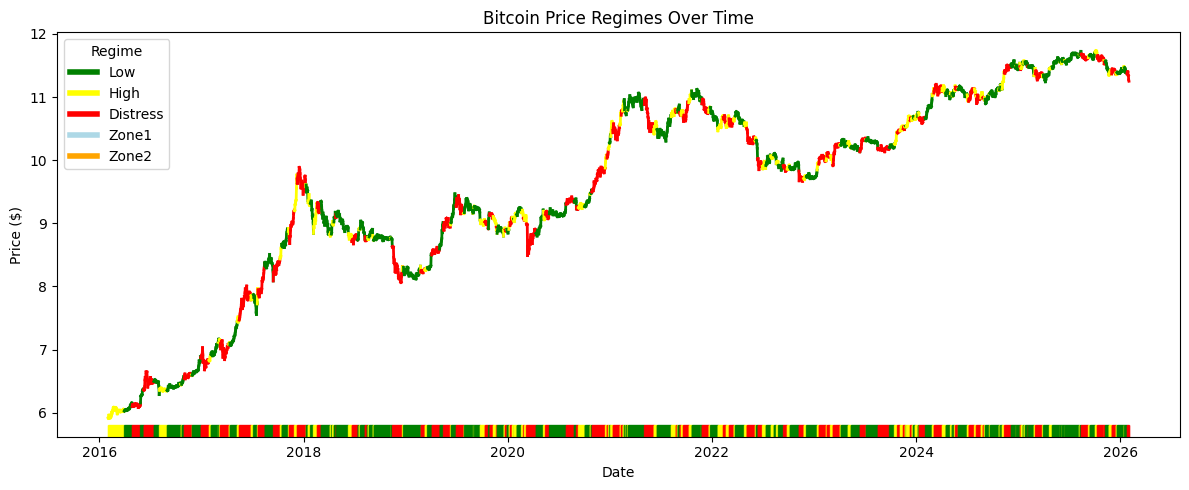

In [7]:
# class distribution
print(df2["regime"].value_counts())

# plot regimes over time
regime_colors = {
    "Low": "green",
    "High": "yellow",
    "Distress": "red",
    "Zone1": "lightblue",
    "Zone2": "orange"
}

df2["date"] = pd.to_datetime(df2["date"])
df2 = df2.sort_values("date")

fig, ax = plt.subplots(figsize=(12, 5))
for i in range(len(df2) - 1):
    x = df2["date"].iloc[i:i+2]
    y = np.log(df2["close"]).iloc[i:i+2]
    regime = df2["regime"].iloc[i]
    ax.plot(x, y, color=regime_colors[regime], linewidth=2)

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")

#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
#ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))


for i in range(len(df2) - 1):
    x0 = df2["date"].iloc[i]
    x1 = df2["date"].iloc[i+1]
    regime = df2["regime"].iloc[i]
    ax.axvspan(x0, x1,
               ymin=0.0, ymax=0.03,
               color=regime_colors[regime],
               alpha=0.8)

ax.set_title("Bitcoin Price Regimes Over Time")
handles = [plt.Line2D([0], [0], color=color, lw=4) for color in regime_colors.values()]
labels = regime_colors.keys()
ax.legend(handles, labels, title="Regime", loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
# export to csv for use in regime-aware models
df2.to_csv("data/df_with_regimes.csv", index=False)